In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, confusion_matrix
import joblib  # Used to save our trained model file

In [3]:
# Load the dataset
df = pd.read_csv("trainingdata.csv")

# Display basic information and the first few rows
print(f"Dataset Shape: {df.shape}")
print("\n--- Class Distribution ---")
print(df['behavior'].value_counts())
df.head()

Dataset Shape: (8000, 4)

--- Class Distribution ---
behavior
0    2720
1    2640
2    2640
Name: count, dtype: int64


,times_talked,items_stolen,weapon_equipped,behavior
0,2,4,0,1
1,36,0,0,0
2,4,11,0,2
3,7,0,0,0
4,3,4,0,1


In [4]:
# Separate features (X) and target (y)
X = df[['times_talked', 'items_stolen', 'weapon_equipped']]
y = df['behavior']

# Split into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")

Training features shape: (6400, 3)
Testing features shape: (1600, 3)


In [5]:
# Initialize the Gaussian Naive Bayes Classifier
classifier = GaussianNB()

# Train the model
classifier.fit(X_train, y_train)
print("[+] Naive Bayes Behavior Classifier Trained Successfully!")

[+] Naive Bayes Behavior Classifier Trained Successfully!


=== Classification Report ===
                precision    recall  f1-score   support

  Friendly (0)       1.00      0.98      0.99       544
Suspicious (1)       0.91      1.00      0.95       528
Aggressive (2)       1.00      0.92      0.96       528

      accuracy                           0.97      1600
     macro avg       0.97      0.97      0.97      1600
  weighted avg       0.97      0.97      0.97      1600



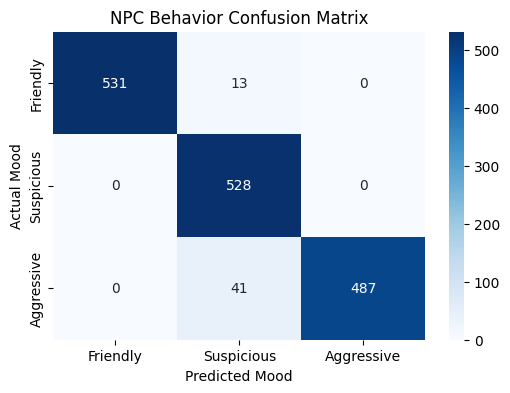

In [6]:
# Predict on the test set
y_pred = classifier.predict(X_test)

# Print Classification Report
print("=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=["Friendly (0)", "Suspicious (1)", "Aggressive (2)"]))

# Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=["Friendly", "Suspicious", "Aggressive"],
            yticklabels=["Friendly", "Suspicious", "Aggressive"])
plt.title("NPC Behavior Confusion Matrix")
plt.xlabel("Predicted Mood")
plt.ylabel("Actual Mood")
plt.show()

In [7]:
# Save the model to a file
model_filename = "npc_behavior_model.pkl"
joblib.dump(classifier, model_filename)

print(f"[+] Saved trained model as '{model_filename}'")
print("You can now move this file into your Flask project folder!")

[+] Saved trained model as 'npc_behavior_model.pkl'
You can now move this file into your Flask project folder!
